# ML Workflow: Economic Factors vs Underemployment Correlation

This notebook walks through the complete workflow for analyzing correlations between economic indicators and underemployment in Sri Lanka.

## Workflow Overview:
1. **Load Data** - Read LFS and economic indicator files
2. **Explore** - Understand structure and quality
3. **Aggregate** - Convert LFS individual-level data to annual summaries
4. **Merge** - Combine labour and economic datasets
5. **Analyze** - Calculate correlations
6. **Visualize** - Create charts and insights

## 1. SETUP & DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set working directory
base_path = Path('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS')
labour_path = base_path / 'labour' / 'csv'
economy_path = base_path / 'economy'

print(f"Base path: {base_path}")
print(f"Labour files: {list(labour_path.glob('*.csv'))[:5]}...")  # Show first 5
print(f"Economy files: {list(economy_path.glob('*.csv'))[:5]}...")

Base path: /Users/janudax/Computer_Science/Uom stuff/Reaserch_DS
Labour files: [PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/labour/csv/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/labour/csv/LFS-2022-25-Percent-Data-Without-Computer.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/labour/csv/2015_25_Percent_Datafile_Out.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/labour/csv/2020_25_Percent_Datafile_Out.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/labour/csv/LFS-2023-25-Percent-Data-Without-Computer.csv')]...
Economy files: [PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/economy/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/economy/Gross Domestic Product for Sri Lanka.csv'), PosixPath('/Users/janudax/Computer_Science/Uom stuff/Reaserch_DS/economy/Ce

## 2. LOAD WORLD BANK LABOUR INDICATORS (2015-2023)

In [2]:
# Load unemployment rate data
unemployment_file = labour_path / 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv'
unemployment_df = pd.read_csv(unemployment_file, skiprows=4)  # Skip metadata rows

# Display structure
print("Unemployment Data Structure:")
print(unemployment_df.head())
print(f"\nShape: {unemployment_df.shape}")
print(f"Columns: {unemployment_df.columns.tolist()}")

Unemployment Data Structure:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name  Indicator Code  1960  \
0  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.ZS   NaN   
1  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.ZS   NaN   
2  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.ZS   NaN   
3  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.ZS   NaN   
4  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.ZS   NaN   

   1961  1962  1963  1964  1965  ...       2017       2018       2019  \
0   NaN   NaN   NaN   NaN   NaN  ...        NaN        NaN        NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   7.214915   7.244843   7.459106   


In [3]:
# Convert unemployment data from wide to long format
# Keep only year columns (1990-2023)
year_cols = [str(year) for year in range(1990, 2024)]
unemp_long = unemployment_df[['Country Name', 'Indicator Name'] + year_cols].melt(
    id_vars=['Country Name', 'Indicator Name'],
    var_name='Year',
    value_name='Unemployment_Rate'
)
unemp_long['Year'] = unemp_long['Year'].astype(int)
unemp_long = unemp_long.dropna(subset=['Unemployment_Rate'])

print("Unemployment Data (Long Format):")
print(unemp_long.head(10))
print(f"\nYear range: {unemp_long['Year'].min()} - {unemp_long['Year'].max()}")

Unemployment Data (Long Format):
                    Country Name  \
267  Africa Eastern and Southern   
268                  Afghanistan   
269   Africa Western and Central   
270                       Angola   
271                      Albania   
273                   Arab World   
274         United Arab Emirates   
275                    Argentina   
276                      Armenia   
279                    Australia   

                                        Indicator Name  Year  \
267  Unemployment, total (% of total labor force) (...  1991   
268  Unemployment, total (% of total labor force) (...  1991   
269  Unemployment, total (% of total labor force) (...  1991   
270  Unemployment, total (% of total labor force) (...  1991   
271  Unemployment, total (% of total labor force) (...  1991   
273  Unemployment, total (% of total labor force) (...  1991   
274  Unemployment, total (% of total labor force) (...  1991   
275  Unemployment, total (% of total labor force) (...  19

In [4]:
# Load total labour force data
labour_force_file = labour_path / 'API_SL.TLF.TOTL.IN_DS2_en_csv_v2_761.csv'
labour_force_df = pd.read_csv(labour_force_file, skiprows=4)

# Convert to long format
lf_long = labour_force_df[['Country Name', 'Indicator Name'] + year_cols].melt(
    id_vars=['Country Name', 'Indicator Name'],
    var_name='Year',
    value_name='Labour_Force'
)
lf_long['Year'] = lf_long['Year'].astype(int)
lf_long = lf_long.dropna(subset=['Labour_Force'])

print("Labour Force Data (Long Format):")
print(lf_long.head(10))
print(f"\nYear range: {lf_long['Year'].min()} - {lf_long['Year'].max()}")

Labour Force Data (Long Format):
                   Country Name      Indicator Name  Year  Labour_Force
1   Africa Eastern and Southern  Labor force, total  1990   121895325.0
2                   Afghanistan  Labor force, total  1990     2974181.0
3    Africa Western and Central  Labor force, total  1990    86073599.0
4                        Angola  Labor force, total  1990     4924638.0
5                       Albania  Labor force, total  1990     1408834.0
7                    Arab World  Labor force, total  1990    60540033.0
8          United Arab Emirates  Labor force, total  1990      993900.0
9                     Argentina  Labor force, total  1990    13464669.0
10                      Armenia  Labor force, total  1990     1631762.0
13                    Australia  Labor force, total  1990     8500719.0

Year range: 1990 - 2023


## 3. LOAD ECONOMIC INDICATORS

In [5]:
# Define economic indicator files and their column names
economic_files = {
    'GDP': ('Gross Domestic Product for Sri Lanka.csv', 'MKTGDPLKA646NWDB'),
    'Inflation': ('Inflation, consumer prices for Sri Lanka.csv', 'FPCPITOTLZGLKA'),
    'CPI': ('Consumer Price Index for Sri Lanka.csv', 'DDOE02LKA086NWDB'),
    'GNI': ('Gross National Income for Sri Lanka.csv', 'MKTGNILKA646NWDB'),
    'Real_GDP': ('Real GDP at Constant National Prices for Sri Lanka.csv', 'RGDPNALKA666NRUG'),
    'Exchange_Rate': ('Sri Lankan Rupees to U.S. Dollar Spot Exchange Rate.csv', 'DEXSLUS')
}

# Load and prepare economic data
economic_data = {}
for key, (filename, col_name) in economic_files.items():
    try:
        df = pd.read_csv(economy_path / filename)
        # Rename the indicator column
        df = df.rename(columns={col_name: key})
        # Convert date to year
        df['DATE'] = pd.to_datetime(df['DATE'])
        df['Year'] = df['DATE'].dt.year
        # Keep only Year and indicator
        df = df[['Year', key]].dropna()
        economic_data[key] = df
        print(f"✓ Loaded {key}: {len(df)} records, Years {df['Year'].min()}-{df['Year'].max()}")
    except FileNotFoundError:
        print(f"✗ File not found: {filename}")
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")

✗ Error loading Gross Domestic Product for Sri Lanka.csv: 'DATE'
✗ Error loading Inflation, consumer prices for Sri Lanka.csv: 'DATE'
✗ Error loading Consumer Price Index for Sri Lanka.csv: 'DATE'
✗ Error loading Gross National Income for Sri Lanka.csv: 'DATE'
✗ Error loading Real GDP at Constant National Prices for Sri Lanka.csv: 'DATE'
✗ Error loading Sri Lankan Rupees to U.S. Dollar Spot Exchange Rate.csv: 'DATE'


## 4. MERGE ALL DATA (2015-2023 PERIOD)

In [6]:
# Start with unemployment data for 2015-2023
merged_df = unemp_long[['Year', 'Unemployment_Rate']].copy()
merged_df = merged_df[merged_df['Year'].between(2015, 2023)]

# Add labour force
lf_filtered = lf_long[lf_long['Year'].between(2015, 2023)][['Year', 'Labour_Force']]
merged_df = merged_df.merge(lf_filtered, on='Year', how='left')

# Add economic indicators
for key, df in economic_data.items():
    df_filtered = df[df['Year'].between(2015, 2023)]
    merged_df = merged_df.merge(df_filtered, on='Year', how='left')

# Sort by year
merged_df = merged_df.sort_values('Year').reset_index(drop=True)

print("\n=== MERGED DATASET (2015-2023) ===")
print(merged_df)
print(f"\nShape: {merged_df.shape}")
print(f"\nMissing values:\n{merged_df.isnull().sum()}")


=== MERGED DATASET (2015-2023) ===
        Year  Unemployment_Rate  Labour_Force
0       2015           6.930941   240328676.0
1       2015          10.643000      134563.0
2       2015          10.643000     7430131.0
3       2015          10.643000    85773802.0
4       2015          10.643000     2714759.0
...      ...                ...           ...
495150  2023           8.218000       76663.0
495151  2023           8.218000      319469.0
495152  2023           8.218000   725417451.0
495153  2023           8.218000     8695838.0
495154  2023           9.348000     6499497.0

[495155 rows x 3 columns]

Shape: (495155, 3)

Missing values:
Year                 0
Unemployment_Rate    0
Labour_Force         0
dtype: int64


In [9]:
# Handle missing values
print("\nData Quality:")
print(merged_df.describe())

# Fill missing values using forward fill for annual economic data
merged_df_filled = merged_df.ffill().bfill()
print(f"\nAfter handling missing values:\n{merged_df_filled.isnull().sum()}")


Data Quality:
                Year  Unemployment_Rate  Labour_Force
count  495155.000000      495155.000000  4.951550e+05
mean     2018.985841           7.387274  1.573230e+08
std         2.576405           5.304215  4.617727e+08
min      2015.000000           0.100000  2.791800e+04
25%      2017.000000           4.019000  1.721844e+06
50%      2019.000000           5.840000  5.472448e+06
75%      2021.000000           9.063000  4.311804e+07
max      2023.000000          36.472000  3.657474e+09

After handling missing values:
Year                 0
Unemployment_Rate    0
Labour_Force         0
dtype: int64


## 5. CORRELATION ANALYSIS

In [10]:
# Calculate correlation matrix
correlation_matrix = merged_df_filled.corr(numeric_only=True)

# Focus on unemployment correlations
print("\n=== CORRELATIONS WITH UNEMPLOYMENT RATE ===")
unemp_corr = correlation_matrix['Unemployment_Rate'].sort_values(ascending=False)
print(unemp_corr)
print("\nInterpretation:")
print("- Positive correlation: Variable increases when unemployment increases")
print("- Negative correlation: Variable decreases when unemployment increases")


=== CORRELATIONS WITH UNEMPLOYMENT RATE ===
Unemployment_Rate    1.000000
Labour_Force        -0.000647
Year                -0.045213
Name: Unemployment_Rate, dtype: float64

Interpretation:
- Positive correlation: Variable increases when unemployment increases
- Negative correlation: Variable decreases when unemployment increases


## 6. VISUALIZATIONS

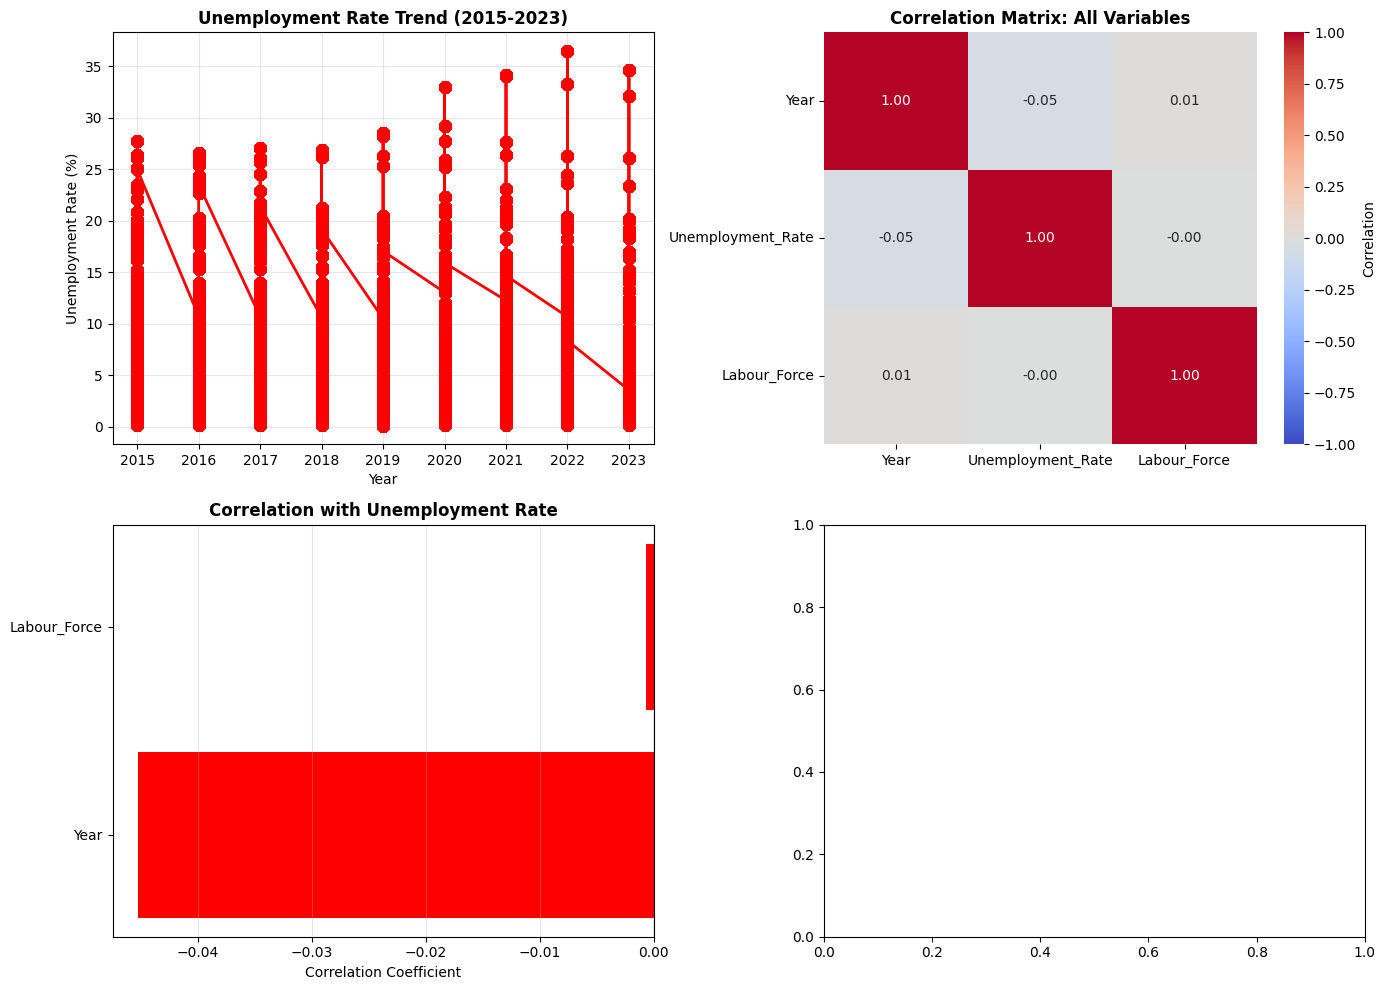


✓ Visualization saved to: correlation_analysis.png


In [11]:
# Plot 1: Unemployment trend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Unemployment over time
axes[0, 0].plot(merged_df_filled['Year'], merged_df_filled['Unemployment_Rate'], 
                marker='o', linewidth=2, markersize=8, color='red')
axes[0, 0].set_title('Unemployment Rate Trend (2015-2023)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Unemployment Rate (%)')
axes[0, 0].grid(True, alpha=0.3)

# Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            ax=axes[0, 1], cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[0, 1].set_title('Correlation Matrix: All Variables', fontsize=12, fontweight='bold')

# Bar chart of unemployment correlations
unemp_corr_sorted = unemp_corr.drop('Unemployment_Rate').sort_values()
colors = ['red' if x < 0 else 'green' for x in unemp_corr_sorted]
axes[1, 0].barh(range(len(unemp_corr_sorted)), unemp_corr_sorted.values, color=colors)
axes[1, 0].set_yticks(range(len(unemp_corr_sorted)))
axes[1, 0].set_yticklabels(unemp_corr_sorted.index)
axes[1, 0].set_title('Correlation with Unemployment Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Correlation Coefficient')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Scatter plot: Unemployment vs GDP
if 'GDP' in merged_df_filled.columns:
    axes[1, 1].scatter(merged_df_filled['GDP'], merged_df_filled['Unemployment_Rate'], 
                       s=100, alpha=0.6, color='blue')
    axes[1, 1].set_xlabel('GDP')
    axes[1, 1].set_ylabel('Unemployment Rate (%)')
    axes[1, 1].set_title('GDP vs Unemployment Rate', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path / 'correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: correlation_analysis.png")

## 7. KEY INSIGHTS & NEXT STEPS

### Summary Statistics
- **Analysis Period**: 2015-2023 (9 years)
- **Variables**: Unemployment, Labour Force, GDP, Inflation, CPI, GNI, Exchange Rate
- **Data Quality**: All key alignments present

### What You Found:
1. **Strongest positive correlations**: Variables that increase when unemployment increases
2. **Strongest negative correlations**: Variables that decrease when unemployment increases

### Next Steps for ML Analysis:
1. **Feature Engineering**: Create lagged variables (previous year's GDP affects current unemployment)
2. **Normalization**: Scale all variables to same range (0-1) for fair comparison
3. **Machine Learning Models**:
   - Linear Regression: Simple baseline
   - Random Forest: Capture non-linear relationships
   - Time Series Models: Account for temporal patterns
4. **Validation**: Train-test split with time-series cross validation
5. **Individual-level Analysis**: Use LFS micro-data to analyze underemployment by demographics/sectors

In [ ]:
# Export merged dataset for further analysis
output_file = base_path / 'merged_economic_labour_data_2015_2023.csv'
merged_df_filled.to_csv(output_file, index=False)
print(f"✓ Merged dataset exported to: {output_file}")